## Helmut Müller
# Woche 7: Data Cleaning - NHANES - Depression  

**Ziel dieser Übung:** Nachdem Sie die wichtigsten Aspekte des Data Cleanings am Airbnb-Beispiel kennengelernt haben, wenden Sie dieses Wissen Schritt für Schritt auf Ihren eigenen Datensatz an.

**Arbeitsweise:**
- Arbeiten Sie die Aufgaben nacheinander durch
- Nutzen Sie die Code-Zellen für Ihre Implementierung
- Orientieren Sie sich an den Beispielen aus dem Airbnb-Notebook
- Das bereinigte Dataset speichern Sie am Ende ab

---
## 1. Daten einlesen und Bibliotheken importieren

**Aufgabe:** Importieren Sie die notwendigen Bibliotheken und laden Sie Ihren Datensatz.

**Hinweise:**
- Importieren Sie: `pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`
- Setzen Sie einen Zufallsseed für Reproduzierbarkeit
- Laden Sie Ihren CSV-Datensatz mit `pd.read_csv()`

In [1]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)


mittels **SEQN - Respondent sequence number** zusammenzuführende Datendateien und die darin enthaltenden Variablen:
- Demographic Variables and Sample Weights (DEMO_L, Demographics Data):
  - RIAGENDR - Gender
  - RIDAGEYR - Age in years at screening
  - DMDEDUC2 - Education level - Adults 20+
  - DMDMARTZ - Marital status
  - INDFMPIR - Ratio of family income to poverty
- Body Measures (BMX_L, Examination Data):
  - BMXBMI - Body Mass Index (kg/m**2)
- Occupation (OCQ_L, Questionnaire Data):
  - OCD150 - Type of work done last week
- Sleep Disorders (SLQ_L, Questionnaire Data)
  - SLD012 - Sleep hours - weekdays or workdays
  - SLD013 - Sleep hours - weekends
  > abgeleitete Variable: ASH - Average Sleep Hours 
- Physical Activity (PAQ_L, Questionnaire Data):
  - PAD790Q - Frequency of moderate LTPA
  - PAD790U - Moderate LTPA unit (day/week/month/year)
  - PAD800 - Minutes moderate LTPA
  - PAD810Q - Frequency of vigorous LTPA
  - PAD810U - Vigorous LTPA unit (day/week/month/year)
  - PAD820 - Minutes vigorous LTPA
  > abgeleitete Variable: MEMPW - moderate equivalent minutes per week
- Mental Health - Depression Screener (DPQ_L, Questionnaire Data):
  - DPQ010 - Have little interest in doing things
  - DPQ020 - Feeling down, depressed, or hopeless
  - DPQ030 - Trouble sleeping or sleeping too much
  - DPQ040 - Feeling tired or having little energy
  - DPQ050 - Poor appetite or overeating
  - DPQ060 - Feeling bad about yourself
  - DPQ070 - Trouble concentrating on things
  - DPQ080 - Moving or speaking slowly or too fast
  - DPQ090 - Thought you would be better off dead
  - DPQ100 - Difficulty these problems have caused
  > PHQ-9 Score: Summe DPQ010:DPQ90

In [2]:
#Import der 6 Dataframes
df_demo = pd.read_sas(os.path.join("data", "DEMO_L.xpt"))
df_bmx = pd.read_sas(os.path.join("data", "BMX_L.xpt"))
df_ocq = pd.read_sas(os.path.join("data", "OCQ_L.xpt"))
df_slq = pd.read_sas(os.path.join("data", "SLQ_L.xpt"))
df_paq = pd.read_sas(os.path.join("data", "PAQ_L.xpt"))
df_dpq = pd.read_sas(os.path.join("data", "DPQ_L.xpt"))

df_list = [
    ("Demographic Variables and Sample Weights (DEMO_L, Demographics Data)", df_demo), 
    ("Body Measures (BMX_L, Examination Data)", df_bmx), 
    ("Occupation (OCQ_L, Questionnaire Data)", df_ocq), 
    ("Sleep Disorders (SLQ_L, Questionnaire Data)", df_slq), 
    ("Physical Activity (PAQ_L, Questionnaire Data)", df_paq), 
    ("Mental Health - Depression Screener (DPQ_L, Questionnaire Data)", df_dpq)
]

---
## 2. Ersten Überblick verschaffen

**Aufgabe:** Verschaffen Sie sich einen ersten Überblick über Ihren Datensatz.

**Was Sie prüfen sollten:**
- Wie viele Zeilen und Spalten hat der Datensatz?
- Welche Spalten gibt es und welche Datentypen haben sie?
- Wie sehen die ersten Zeilen aus?

In [3]:
# zunächst Informationen für einzelne Datendateien
for name, df_part in df_list:
    print("Dataframe:", name)
    print("Dimensionen:", df_part.shape)
    print("\nSpalten:", df_part.columns.tolist())
    df_part.info()
    display(df_part.head())
    display(df_part.describe())
    print("\n")

Dataframe: Demographic Variables and Sample Weights (DEMO_L, Demographics Data)
Dimensionen: (11933, 27)

Spalten: ['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMDBORN4', 'DMDYRUSR', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'DMDHHSIZ', 'DMDHRGND', 'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU', 'INDFMPIR']
<class 'pandas.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      11933 non-null  float64
 1   SDDSRVYR  11933 non-null  float64
 2   RIDSTATR  11933 non-null  float64
 3   RIAGENDR  11933 non-null  float64
 4   RIDAGEYR  11933 non-null  float64
 5   RIDAGEMN  377 non-null    float64
 6   RIDRETH1  11933 non-null  float64
 7   RIDRETH3  11933 non-null  float64
 8   RIDEXMON  8860 non-null   float64
 9   RIDEXAGM  2787 non-null   float64

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,DMDBORN4,DMDYRUSR,DMDEDUC2,DMDMARTZ,RIDEXPRG,DMDHHSIZ,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,2.0,2.0,6.0,5.0,1.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,50055.450807,54374.463898,173.0,2.0,5.00
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,2.0,1.0,NaN,5.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,29087.450605,34084.721548,173.0,2.0,5.00
2,130380.0,12.0,2.0,2.0,44.0,NaN,2.0,2.0,1.0,NaN,2.0,2.0,6.0,3.0,1.0,2.0,7.0,NaN,NaN,NaN,NaN,NaN,80062.674301,81196.277992,174.0,1.0,1.41
3,130381.0,12.0,2.0,2.0,5.0,NaN,5.0,7.0,1.0,71.0,NaN,1.0,NaN,NaN,NaN,NaN,2.0,2.0,2.0,2.0,3.0,NaN,38807.268902,55698.607106,182.0,2.0,1.53
4,130382.0,12.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,34.0,NaN,1.0,NaN,NaN,NaN,NaN,4.0,2.0,2.0,3.0,1.0,2.0,30607.519774,36434.146346,182.0,2.0,3.60


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,DMDBORN4,DMDYRUSR,DMDEDUC2,DMDMARTZ,RIDEXPRG,DMDHHSIZ,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR
count,11933.000000,11933.0,11933.000000,11933.000000,1.193300e+04,3.770000e+02,11933.000000,11933.000000,8860.000000,2.787000e+03,8301.000000,11914.000000,1875.000000,7794.000000,7792.000000,1503.000000,11933.000000,4115.000000,4124.000000,3746.000000,4020.000000,2127.000000,11933.000000,1.193300e+04,11933.000000,11933.000000,9.892000e+03
mean,136344.000000,12.0,1.742479,1.532808,3.831786e+01,1.162865e+01,3.104584,3.320540,1.520203,1.219085e+02,1.916998,1.157378,7.334933,3.804978,1.778491,2.236860,3.242772,1.564277,2.539525,2.171383,1.381095,2.275035,27404.135674,2.740414e+04,179.918294,1.491746,2.708174e+00
std,3444.904716,0.0,0.437287,0.498943,2.560199e+01,6.805429e+00,1.076346,1.518379,0.499620,6.715865e+01,0.282376,0.364172,15.829158,1.153750,3.101080,0.485254,1.699512,0.495912,0.641094,0.660132,0.681421,0.694050,19449.155209,2.796296e+04,4.309624,0.499953,1.670119e+00
min,130378.000000,12.0,1.000000,1.000000,5.397605e-79,5.397605e-79,1.000000,1.000000,1.000000,5.397605e-79,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4584.463196,5.397605e-79,173.000000,1.000000,5.397605e-79
25%,133361.000000,12.0,1.000000,1.000000,1.300000e+01,6.000000e+00,3.000000,3.000000,1.000000,6.600000e+01,2.000000,1.000000,3.000000,3.000000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000,14331.753594,5.397605e-79,176.000000,1.000000,1.180000e+00
50%,136344.000000,12.0,2.000000,2.000000,3.700000e+01,1.100000e+01,3.000000,3.000000,2.000000,1.220000e+02,2.000000,1.000000,6.000000,4.000000,1.000000,2.000000,3.000000,2.000000,2.000000,2.000000,1.000000,2.000000,21670.185970,2.171785e+04,180.000000,1.000000,2.500000e+00
75%,139327.000000,12.0,2.000000,2.000000,6.200000e+01,1.700000e+01,4.000000,4.000000,2.000000,1.795000e+02,2.000000,1.000000,6.000000,5.000000,2.000000,3.000000,4.000000,2.000000,3.000000,3.000000,2.000000,3.000000,33831.331556,3.834115e+04,184.000000,2.000000,4.500000e+00
max,142310.000000,12.0,2.000000,2.000000,8.000000e+01,2.400000e+01,5.000000,7.000000,2.000000,2.390000e+02,7.000000,2.000000,99.000000,9.000000,99.000000,3.000000,7.000000,2.000000,4.000000,3.000000,3.000000,3.000000,170968.343177,2.271083e+05,187.000000,2.000000,5.000000e+00




Dataframe: Body Measures (BMX_L, Examination Data)
Dimensionen: (8860, 22)

Spalten: ['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML', 'BMXARMC', 'BMIARMC', 'BMXWAIST', 'BMIWAIST', 'BMXHIP', 'BMIHIP']
<class 'pandas.DataFrame'>
RangeIndex: 8860 entries, 0 to 8859
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      8860 non-null   float64
 1   BMDSTATS  8860 non-null   float64
 2   BMXWT     8754 non-null   float64
 3   BMIWT     345 non-null    float64
 4   BMXRECUM  454 non-null    float64
 5   BMIRECUM  18 non-null     float64
 6   BMXHEAD   70 non-null     float64
 7   BMIHEAD   0 non-null      float64
 8   BMXHT     8499 non-null   float64
 9   BMIHT     134 non-null    float64
 10  BMXBMI    8471 non-null   float64
 11  BMDBMIC   2492 non-null   float64
 12  BMXLEG    7335 non-null   float64


,SEQN,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,BMXBMI,BMDBMIC,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP
0,130378.0,1.0,86.9,NaN,NaN,NaN,NaN,NaN,179.5,NaN,27.0,NaN,42.8,NaN,42.0,NaN,35.7,NaN,98.3,NaN,102.9,NaN
1,130379.0,1.0,101.8,NaN,NaN,NaN,NaN,NaN,174.2,NaN,33.5,NaN,38.5,NaN,38.7,NaN,33.7,NaN,114.7,NaN,112.4,NaN
2,130380.0,1.0,69.4,NaN,NaN,NaN,NaN,NaN,152.9,NaN,29.7,NaN,38.5,NaN,35.5,NaN,36.3,NaN,93.5,NaN,98.0,NaN
3,130381.0,1.0,34.3,NaN,NaN,NaN,NaN,NaN,120.1,NaN,23.8,4.0,NaN,NaN,25.4,NaN,23.4,NaN,70.4,NaN,NaN,NaN
4,130382.0,3.0,13.6,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,NaN


...

,SEQN,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,PAD680
0,130378.0,3.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,360.0
1,130379.0,4.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,480.0
2,130380.0,1.000000e+00,b'W',20.0,5.397605e-79,b'',NaN,240.0
3,130384.0,5.397605e-79,b'',NaN,5.397605e-79,b'',NaN,60.0
4,130385.0,1.000000e+00,b'D',90.0,1.000000e+00,b'W',60.0,180.0


,SEQN,PAD790Q,PAD800,PAD810Q,PAD820,PAD680
count,8153.000000,8.135000e+03,6390.000000,8.139000e+03,3687.000000,8.138000e+03
mean,136378.394579,6.014247e+01,93.437715,4.921084e+01,97.571467,4.469827e+02
std,3440.455897,7.417083e+02,544.415142,6.852722e+02,605.421908,9.174642e+02
min,130378.000000,5.397605e-79,1.000000,5.397605e-79,1.000000,5.397605e-79
25%,133395.000000,1.000000e+00,30.000000,5.397605e-79,30.000000,1.800000e+02
50%,136419.000000,2.000000e+00,60.000000,5.397605e-79,45.000000,3.000000e+02
75%,139346.000000,4.000000e+00,60.000000,2.000000e+00,60.000000,4.800000e+02
max,142310.000000,9.999000e+03,9999.000000,9.999000e+03,9999.000000,9.999000e+03




Dataframe: Mental Health - Depression Screener (DPQ_L, Questionnaire Data)
Dimensionen: (6337, 11)

Spalten: ['SEQN', 'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060', 'DPQ070', 'DPQ080', 'DPQ090', 'DPQ100']
<class 'pandas.DataFrame'>
RangeIndex: 6337 entries, 0 to 6336
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEQN    6337 non-null   float64
 1   DPQ010  5519 non-null   float64
 2   DPQ020  5518 non-null   float64
 3   DPQ030  5516 non-null   float64
 4   DPQ040  5514 non-null   float64
 5   DPQ050  5513 non-null   float64
 6   DPQ060  5510 non-null   float64
 7   DPQ070  5508 non-null   float64
 8   DPQ080  5508 non-null   float64
 9   DPQ090  5506 non-null   float64
 10  DPQ100  4167 non-null   float64
dtypes: float64(11)
memory usage: 544.7 KB


,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100
0,130378.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,130379.0,5.397605e-79,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
2,130380.0,5.397605e-79,5.397605e-79,1.000000e+00,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
3,130386.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
4,130387.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,NaN


,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100
count,6337.000000,5.519000e+03,5.518000e+03,5.516000e+03,5.514000e+03,5.513000e+03,5.510000e+03,5.508000e+03,5.508000e+03,5.506000e+03,4.167000e+03
mean,136348.738362,5.109621e-01,4.786154e-01,7.935098e-01,8.601741e-01,5.042627e-01,4.110708e-01,3.948802e-01,2.165940e-01,8.209226e-02,4.792417e-01
std,3439.132476,9.466645e-01,8.387239e-01,1.003693e+00,9.651269e-01,8.605773e-01,7.869793e-01,7.675240e-01,6.850770e-01,4.381644e-01,7.401059e-01
min,130378.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
25%,133337.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
50%,136397.000000,5.397605e-79,5.397605e-79,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
75%,139310.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.397605e-79,5.397605e-79,1.000000e+00
max,142310.000000,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00


Beobachtungen: 
- am wenigsten Einträge im Mental Health-Dataframe

~~-> ich habe mich entschieden vor dem Join schon die Variablen auszuwählen. Somit möchte ich vermeiden, dass durch einen Inner Join Zeilen verloren gehen, weil Variablen fehlen, die ich garnicht verwenden will. Bei einem Outer Join müsste ich entsprechende Zeilen nachträglich entfernen.~~  
-> um die Option zu haben, naträglich auch andere Variablen zu untersuchen, mache ich doch den Outer Join für alle Datendateien außer die der Target Variable. Datensätze ohne die Targetvariable werde ich nicht brauchen. Deshalb scheint ein Inner Join hier sinnvoller.

In [4]:
# vor dem Merge prüfe ich, ob SEQNs doppelt vorkommen
for name, df in df_list:
    print(
        f"{name}:",
        df["SEQN"].duplicated().sum(),
        "doppelte IDs"
    )

Demographic Variables and Sample Weights (DEMO_L, Demographics Data): 0 doppelte IDs
Body Measures (BMX_L, Examination Data): 0 doppelte IDs
Occupation (OCQ_L, Questionnaire Data): 0 doppelte IDs
Sleep Disorders (SLQ_L, Questionnaire Data): 0 doppelte IDs
Physical Activity (PAQ_L, Questionnaire Data): 0 doppelte IDs
Mental Health - Depression Screener (DPQ_L, Questionnaire Data): 0 doppelte IDs


-> dies ist nicht der Fall

In [5]:
# dann Zusammenführen der Datendateien anhand der SEQN und dann Informationen über zusammengeführten Dataframe
df_merged = df_demo 
for df in [df_bmx, df_ocq, df_slq, df_paq]:
    df_merged = df_merged.merge(df, on="SEQN", how="outer")
df_merged = df_merged.merge(df_dpq, on="SEQN", how="inner")

In [6]:
    print("Dimensionen:", df_merged.shape)
    print("\nSpalten:", df_merged.columns.tolist())
    df_merged.info()
    display(df_merged.head())
    display(df_merged.describe())

Dimensionen: (6337, 76)

Spalten: ['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMDBORN4', 'DMDYRUSR', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'DMDHHSIZ', 'DMDHRGND', 'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU', 'INDFMPIR', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML', 'BMXARMC', 'BMIARMC', 'BMXWAIST', 'BMIWAIST', 'BMXHIP', 'BMIHIP', 'OCD150', 'OCQ180', 'OCQ210', 'OCQ215', 'OCQ383', 'SLQ300', 'SLQ310', 'SLD012', 'SLQ320', 'SLQ330', 'SLD013', 'PAD790Q', 'PAD790U', 'PAD800', 'PAD810Q', 'PAD810U', 'PAD820', 'PAD680', 'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060', 'DPQ070', 'DPQ080', 'DPQ090', 'DPQ100']
<class 'pandas.DataFrame'>
RangeIndex: 6337 entries, 0 to 6336
Data columns (total 76 columns):
 #   Column    Non-Null Count  Dtype  
--- 

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,DMDBORN4,DMDYRUSR,DMDEDUC2,DMDMARTZ,RIDEXPRG,DMDHHSIZ,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,BMXBMI,BMDBMIC,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP,OCD150,OCQ180,OCQ210,OCQ215,OCQ383,SLQ300,SLQ310,SLD012,SLQ320,SLQ330,SLD013,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,PAD680,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,2.0,2.0,6.0,5.0,1.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,50055.450807,54374.463898,173.0,2.0,5.00,1.0,86.9,NaN,NaN,NaN,NaN,NaN,179.5,NaN,27.0,NaN,42.8,NaN,42.0,NaN,35.7,NaN,98.3,NaN,102.9,NaN,1.0,40.0,NaN,5.0,NaN,b'21:30',b'07:00',9.5,b'00:00',b'09:00',9.0,3.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,2.0,1.0,NaN,5.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,29087.450605,34084.721548,173.0,2.0,5.00,1.0,101.8,NaN,NaN,NaN,NaN,NaN,174.2,NaN,33.5,NaN,38.5,NaN,38.7,NaN,33.7,NaN,114.7,NaN,112.4,NaN,1.0,32.0,2.0,3.0,NaN,b'21:00',b'06:00',9.0,b'21:00',b'06:00',9.0,4.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,480.0,5.397605e-79,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
2,130380.0,12.0,2.0,2.0,44.0,NaN,2.0,2.0,1.0,NaN,2.0,2.0,6.0,3.0,1.0,2.0,7.0,NaN,NaN,NaN,NaN,NaN,80062.674301,81196.277992,174.0,1.0,1.41,1.0,69.4,NaN,NaN,NaN,NaN,NaN,152.9,NaN,29.7,NaN,38.5,NaN,35.5,NaN,36.3,NaN,93.5,NaN,98.0,NaN,1.0,8.0,2.0,2.0,NaN,b'00:00',b'08:00',8.0,b'00:00',b'09:00',9.0,1.000000e+00,b'W',20.0,5.397605e-79,b'',NaN,240.0,5.397605e-79,5.397605e-79,1.000000e+00,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
3,130386.0,12.0,2.0,1.0,34.0,NaN,1.0,1.0,1.0,NaN,2.0,1.0,NaN,4.0,1.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,30995.282610,39988.452940,179.0,1.0,1.33,1.0,90.6,NaN,NaN,NaN,NaN,NaN,173.3,NaN,30.2,NaN,42.8,NaN,36.2,NaN,35.7,NaN,106.1,NaN,110.6,NaN,1.0,40.0,NaN,5.0,NaN,b'00:00',b'07:30',7.5,b'00:00',b'08:00',8.0,1.000000e+00,b'W',30.0,1.000000e+00,b'M',30.0,180.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
4,130387.0,12.0,2.0,2.0,68.0,NaN,3.0,3.0,2.0,NaN,2.0,1.0,NaN,5.0,3.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,19896.970559,20776.254850,181.0,1.0,1.32,1.0,103.5,NaN,NaN,NaN,NaN,NaN,155.9,NaN,42.6,NaN,36.1,NaN,37.7,NaN,37.4,NaN,122.0,NaN,148.9,NaN,4.0,NaN,NaN,NaN,7.0,b'04:00',b'07:00',3.0,b'03:00',b'08:00',5.0,5.397605e-79,b'',NaN,5.397605e-79,b'',NaN,1200.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,NaN


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,DMDBORN4,DMDYRUSR,DMDEDUC2,DMDMARTZ,RIDEXPRG,DMDHHSIZ,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,BMXBMI,BMDBMIC,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP,OCD150,OCQ180,OCQ210,OCQ215,OCQ383,SLD012,SLD013,PAD790Q,PAD800,PAD810Q,PAD820,PAD680,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100
count,6337.000000,6337.0,6337.0,6337.000000,6337.000000,0.0,6337.000000,6337.000000,6337.000000,264.000000,6337.000000,6337.000000,1278.000000,6064.000000,6063.000000,1134.000000,6337.000000,272.000000,273.000000,252.000000,224.000000,109.000000,6337.000000,6337.000000,6337.000000,6337.000000,5.506000e+03,6337.000000,6248.000000,265.000000,0.0,0.0,0.0,0.0,6262.000000,108.000000,6235.000000,256.000000,5932.00000,340.0,6156.000000,124.0,6153.000000,127.0,6019.000000,259.0,5957.000000,321.0,6337.000000,3229.000000,1088.000000,3432.000000,2641.000000,6272.000000,6270.000000,6.330000e+03,5031.000000,6.330000e+03,2877.000000,6.331000e+03,5.519000e+03,5.518000e+03,5.516000e+03,5.514000e+03,5.513000e+03,5.510000e+03,5.508000e+03,5.508000e+03,5.506000e+03,4.167000e+03
mean,136348.738362,12.0,2.0,1.548998,52.325548,NaN,3.123402,3.309768,1.528641,227.162879,1.913366,1.201673,7.230047,3.839380,1.725383,1.988536,2.624586,1.573529,2.608059,2.138889,1.441964,2.247706,30804.787525,40053.181704,179.728736,1.491400,2.893249e+00,1.137447,82.878132,2.833962,NaN,NaN,NaN,NaN,166.954982,2.592593,29.659326,2.511719,38.44651,1.0,37.644347,1.0,33.493938,1.0,100.455225,1.0,107.580443,1.0,2.366419,496.165067,1.659007,4.965326,3.322984,7.724330,8.289633,4.950742e+01,88.863248,4.187599e+01,94.047967,4.268079e+02,5.109621e-01,4.786154e-01,7.935098e-01,8.601741e-01,5.042627e-01,4.110708e-01,3.948802e-01,2.165940e-01,8.209226e-02,4.792417e-01
std,3439.132476,0.0,0.0,0.497633,18.280888,NaN,0.989329,1.400246,0.499218,6.927104,0.281320,0.401281,14.489603,1.144338,2.500998,0.246513,1.485297,0.495476,0.868277,0.650280,0.693485,0.668829,21243.184657,28986.780636,4.262213,0.499965,1.660074e+00,0.515432,22.464318,0.681727,NaN,NaN,NaN,NaN,10.051394,0.809258,7.395826,0.957867,3.63469,0.0,2.911242,0.0,5.328894,0.0,17.171398,0.0,14.380724,0.0,1.446171,6708.134211,0.551398,3.595590,2.654577,1.601201,1.712416,6.706932e+02,507.935863,6.346160e+02,576.484296,7.929427e+02,9.466645e-01,8.387239e-01,1.003693e+00,9.651269e-01,8.605773e-01,7.869793e-01,7.675240e-01,6.850770e-01,4.381644e-01,7.401059e-01
min,130378.000000,12.0,2.0,1.000000,18.000000,NaN,1.000000,1.000000,1.000000,216.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4584.463196,4581.595095,173.000000,1.000000,5.397605e-79,1.000000,27.900000,1.000000,NaN,NaN,NaN,NaN,133.000000,1.000000,11.100000,1.000000,24.90000,1.0,27.400000,1.0,16.000000,1.0,59.600000,1.0,74.500000,1.0,1.000000,5.000000,1.000000,1.000000,1.000000,2.000000,2.000000,5.397605e-79,1.000000,5.397605e-79,1.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
25%,133337.000000,12.0,2.0,1.000000,37.000000,NaN,3.000000,3.000000,1.000000,221.000000,2.000000,1.000000,4.000000,3.000000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000,16055.974362,20023.635874,176.000000,1.000000,1.380000e+00,1.000000,67.000000,3.000000,NaN,NaN,NaN,NaN,159.700000,3.000000,24.500000,2.000000,36.00000,1.0,35.500000,1.0,29.800000,1.0,88.100000,1.0,97.700000,1.0,1.000000,32.000000,1.000000,5.000000,3.000000,7.000000,7.500000,1.000000e+00,30.000000,5.397605e-79,30.000000,2.400000e+02,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
50%,136397.000000,12.0,2.0,2.000000,56.0000

anschließend wähle ich die Variablen aus, die ich zunächst für die Untersuchung fetgelegt habe. Davoon ausgehend erfolgen die weiteren Cleaning-Steps.

In [7]:
# Auswahl der Variablen
selected_variables = ['SEQN', 'RIAGENDR', 'RIDAGEYR', 'DMDEDUC2', 'DMDMARTZ', \
                         'INDFMPIR', 'BMXBMI', 'OCD150', 'SLD012', 'SLD013', \
                         'PAD790Q', 'PAD790U', 'PAD800', 'PAD810Q', 'PAD810U', 'PAD820', \
                         'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060', \
                         'DPQ070', 'DPQ080', 'DPQ090', 'DPQ100']

df_selected = df_merged[selected_variables]

df_selected_clean = df_selected.copy()

In [8]:
print("Dimensionen:", df_selected.shape)
print("\nSpalten:", df_selected.columns.tolist())
df_selected.info()
display(df_selected.head())
display(df_selected.describe())

Dimensionen: (6337, 26)

Spalten: ['SEQN', 'RIAGENDR', 'RIDAGEYR', 'DMDEDUC2', 'DMDMARTZ', 'INDFMPIR', 'BMXBMI', 'OCD150', 'SLD012', 'SLD013', 'PAD790Q', 'PAD790U', 'PAD800', 'PAD810Q', 'PAD810U', 'PAD820', 'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060', 'DPQ070', 'DPQ080', 'DPQ090', 'DPQ100']
<class 'pandas.DataFrame'>
RangeIndex: 6337 entries, 0 to 6336
Data columns (total 26 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      6337 non-null   float64
 1   RIAGENDR  6337 non-null   float64
 2   RIDAGEYR  6337 non-null   float64
 3   DMDEDUC2  6064 non-null   float64
 4   DMDMARTZ  6063 non-null   float64
 5   INDFMPIR  5506 non-null   float64
 6   BMXBMI    6235 non-null   float64
 7   OCD150    6337 non-null   float64
 8   SLD012    6272 non-null   float64
 9   SLD013    6270 non-null   float64
 10  PAD790Q   6330 non-null   float64
 11  PAD790U   6337 non-null   object 
 12  PAD800    5031 non-null   float64
 13  PAD810Q

,SEQN,RIAGENDR,RIDAGEYR,DMDEDUC2,DMDMARTZ,INDFMPIR,BMXBMI,OCD150,SLD012,SLD013,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100
0,130378.0,1.0,43.0,5.0,1.0,5.00,27.0,1.0,9.5,9.0,3.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,130379.0,1.0,66.0,5.0,1.0,5.00,33.5,1.0,9.0,9.0,4.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,5.397605e-79,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
2,130380.0,2.0,44.0,3.0,1.0,1.41,29.7,1.0,8.0,9.0,1.000000e+00,b'W',20.0,5.397605e-79,b'',NaN,5.397605e-79,5.397605e-79,1.000000e+00,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
3,130386.0,1.0,34.0,4.0,1.0,1.33,30.2,1.0,7.5,8.0,1.000000e+00,b'W',30.0,1.000000e+00,b'M',30.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
4,130387.0,2.0,68.0,5.0,3.0,1.32,42.6,4.0,3.0,5.0,5.397605e-79,b'',NaN,5.397605e-79,b'',NaN,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,NaN


,SEQN,RIAGENDR,RIDAGEYR,DMDEDUC2,DMDMARTZ,INDFMPIR,BMXBMI,OCD150,SLD012,SLD013,PAD790Q,PAD800,PAD810Q,PAD820,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100
count,6337.000000,6337.000000,6337.000000,6064.000000,6063.000000,5.506000e+03,6235.000000,6337.000000,6272.000000,6270.000000,6.330000e+03,5031.000000,6.330000e+03,2877.000000,5.519000e+03,5.518000e+03,5.516000e+03,5.514000e+03,5.513000e+03,5.510000e+03,5.508000e+03,5.508000e+03,5.506000e+03,4.167000e+03
mean,136348.738362,1.548998,52.325548,3.839380,1.725383,2.893249e+00,29.659326,2.366419,7.724330,8.289633,4.950742e+01,88.863248,4.187599e+01,94.047967,5.109621e-01,4.786154e-01,7.935098e-01,8.601741e-01,5.042627e-01,4.110708e-01,3.948802e-01,2.165940e-01,8.209226e-02,4.792417e-01
std,3439.132476,0.497633,18.280888,1.144338,2.500998,1.660074e+00,7.395826,1.446171,1.601201,1.712416,6.706932e+02,507.935863,6.346160e+02,576.484296,9.466645e-01,8.387239e-01,1.003693e+00,9.651269e-01,8.605773e-01,7.869793e-01,7.675240e-01,6.850770e-01,4.381644e-01,7.401059e-01
min,130378.000000,1.000000,18.000000,1.000000,1.000000,5.397605e-79,11.100000,1.000000,2.000000,2.000000,5.397605e-79,1.000000,5.397605e-79,1.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
25%,133337.000000,1.000000,37.000000,3.000000,1.000000,1.380000e+00,24.500000,1.000000,7.000000,7.500000,1.000000e+00,30.000000,5.397605e-79,30.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
50%,136397.000000,2.000000,56.000000,4.000000,1.000000,2.790000e+00,28.300000,1.000000,8.000000,8.000000,2.000000e+00,60.000000,5.397605e-79,45.000000,5.397605e-79,5.397605e-79,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
75%,139310.000000,2.000000,67.000000,5.000000,2.000000,4.940000e+00,33.400000,4.000000,8.500000,9.000000,4.000000e+00,60.000000,2.000000e+00,60.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.397605e-79,5.397605e-79,1.000000e+00
max,142310.000000,2.000000,80.000000,9.000000,99.000000,5.000000e+00,74.800000,9.000000,14.000000,14.000000,9.999000e+03,9999.000000,9.999000e+03,9999.000000,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00


---
## 3. Fehlende Werte identifizieren

**Aufgabe:** Untersuchen Sie Ihren Datensatz auf fehlende Werte.

**Was Sie tun sollten:**
- Zählen Sie fehlende Werte pro Spalte
- Berechnen Sie den Prozentsatz fehlender Werte
- Visualisieren Sie fehlende Werte (optional: Heatmap)

In [9]:
# Fehlende Werte zählen
missing = df_selected_clean.isnull().sum()
# Prozentsatz fehlender Werte berechnen
missing_pct = (missing / len(df_selected_clean)) * 100
missing_df = pd.DataFrame({
    'Spalte': missing.index,
    'Fehlend': missing.values,
    'Prozent': missing_pct.values
})
# missing_df = missing_df[missing_df['Fehlend'] > 0]
display(missing_df)

# Optional: Visualisierung mit Heatmap


,Spalte,Fehlend,Prozent
0,SEQN,0,0.000000
1,RIAGENDR,0,0.000000
2,RIDAGEYR,0,0.000000
3,DMDEDUC2,273,4.308032
4,DMDMARTZ,274,4.323813
5,INDFMPIR,831,13.113461
6,BMXBMI,102,1.609594
7,OCD150,0,0.000000
8,SLD012,65,1.025722
9,SLD013,67,1.057283


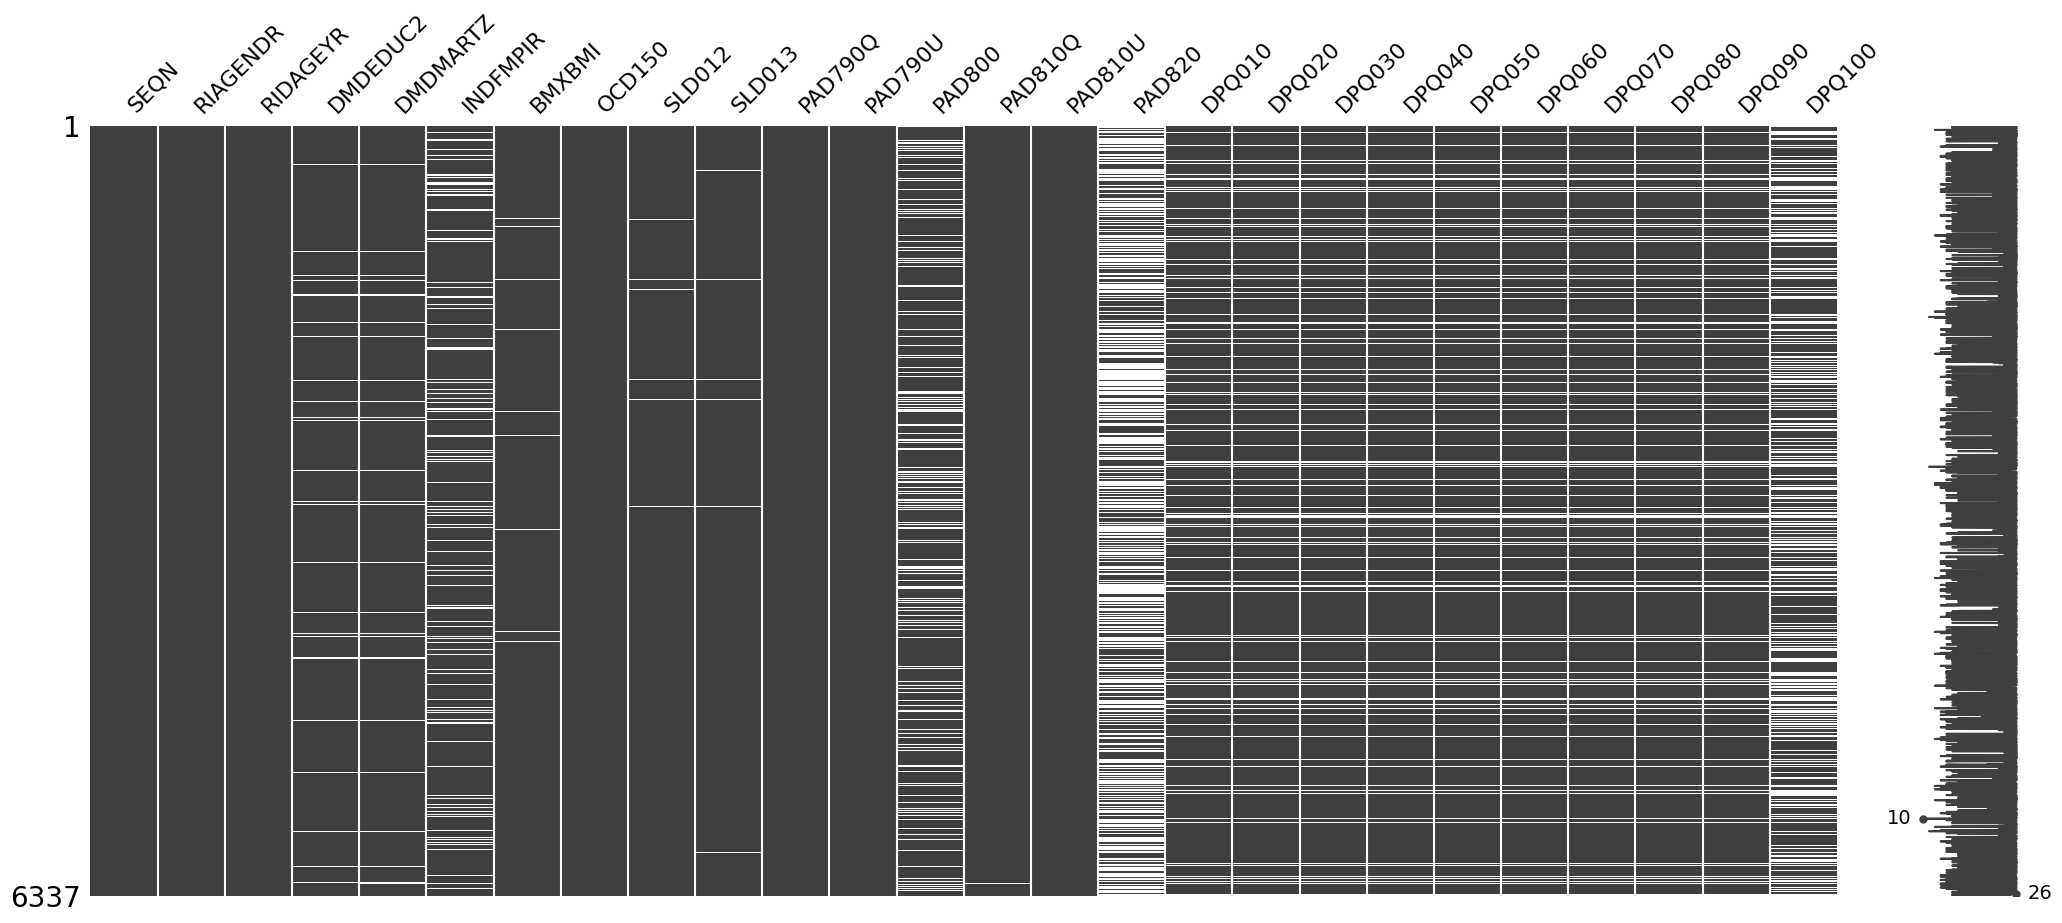

In [10]:
import missingno as msno
msno.matrix(df_selected_clean)
plt.show()

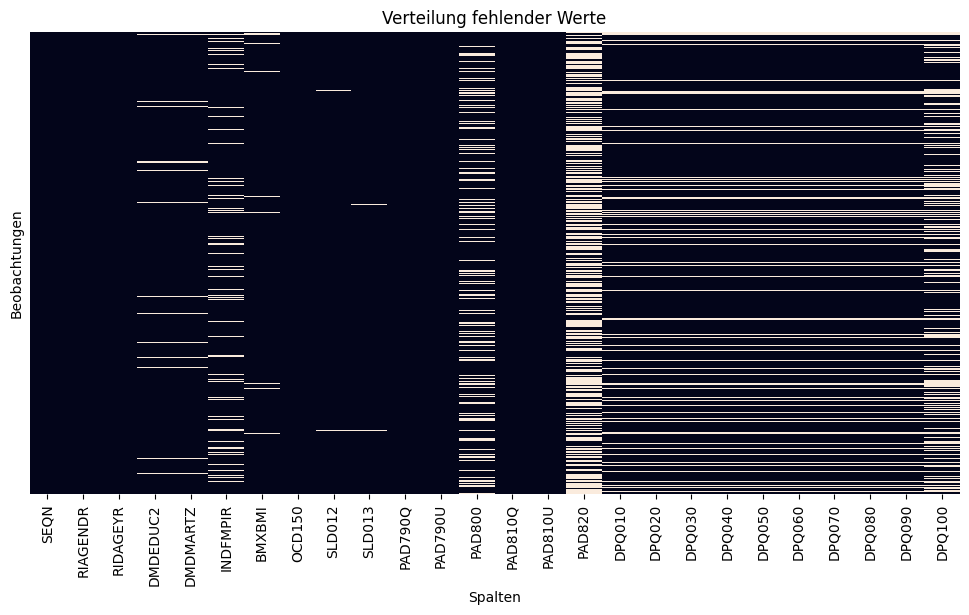

In [11]:
# Missing Values visualisieren
plt.figure(figsize=(12, 6))
sns.heatmap(
    df_selected_clean.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Verteilung fehlender Werte")
plt.xlabel("Spalten")
plt.ylabel("Beobachtungen")
plt.show()

---
## 4. Fehlende Werte behandeln

**Aufgabe:** Entscheiden Sie für jede Spalte mit fehlenden Werten, wie Sie damit umgehen.

**Mögliche Strategien:**
- Zeilen löschen (bei wenigen fehlenden Werten)
- Spalten löschen (bei sehr vielen fehlenden Werten)
- Fehlende Werte imputieren:
  - Numerische Spalten: Median oder Mittelwert
  - Kategoriale Spalten: Modus oder neue Kategorie

**Dokumentieren Sie Ihre Entscheidungen!**

**Erwägungen Spalte für Spalte:**  
Da ich meine Zielvariable aus den Variablen DPQ010 bis DPQ090 berechnet, fange ich mit diesen Variablen an.  
Da der PHQ9-Score die Summe dieser Einzelscores ist, kann ich "refused", "don't know" und "missing" Values nicht verwerten. Deshalb können entsprechende Zeilen gelöscht werden.

Werte von 0 wurden durch den SAS-Import auf 5.397605e-79 gesetzt. Das wurde im folgenden behoben. Alternativ zur Nutzung der Cleaning-Maske hätte man möglicherweise auch einfach den df rounden können (entweder alles, oder nur die entsprechenden Spalten).

In [12]:
# Strategie 1: Zeilen mit fehlenden Werten löschen (falls anwendbar)
# df_selected_clean = df_selected_clean.dropna(subset=['DPQ010', 'DPQ020', 'DPQ030', \
#                                                      'DPQ040', 'DPQ050', 'DPQ060', \
#                                                      'DPQ070', 'DPQ080', 'DPQ090'])
# nicht mehr nötig, im nächsten Schritt, werden auch die NaN-Werte gelöscht
# zusätzlich können direkt auch die Zeilen mit den Antworten 7 = 'refused' und 9 = 'don't know' gelöscht werden.
target_cols = ['DPQ010', 'DPQ020', 'DPQ030', \
               'DPQ040', 'DPQ050', 'DPQ060', \
               'DPQ070', 'DPQ080', 'DPQ090']

# dafür müssten zuerst die Werte von 5.397605e-79 auf 0 gesetzt werden, damit anschließend alle Werte,
# die nicht 0, 1, 2 oder 3 sind entfernt werden können. Während das 0-Setzen auch für DPQ100 erfolgen soll,
# sollen die Zeilen, in denen DPQ100 keinen Wert hat nicht entfernt werden, da DPQ100 nicht Teil des HPQ9-Scores ist.

target_cols_0 = target_cols + ['DPQ100']
threshold = 1e-10 

for col in target_cols_0:
    mask_is_tiny = np.abs(df_selected_clean[col]) < threshold
    df_selected_clean.loc[mask_is_tiny, col] = 0
    
    print(f"{col}: Korrigierte {mask_is_tiny.sum()} extreme Werte auf 0.")

# jetzt nach erlaubten Werten filtern
valid_mask = df_selected_clean[target_cols].isin([0, 1, 2, 3]).all(axis=1)

print(f"\nFilter-Ergebnis:")
print(f"Gültige Zeilen: {valid_mask.sum()} von {len(df_selected_clean)}")

df_selected_clean = df_selected_clean[valid_mask].copy()
df_selected_clean[target_cols] = df_selected_clean[target_cols].astype(int)
df_selected_clean['DPQ100'] = df_selected_clean['DPQ100'].astype('Int64')

df_selected_clean.head()



DPQ010: Korrigierte 3703 extreme Werte auf 0.
DPQ020: Korrigierte 3674 extreme Werte auf 0.
DPQ030: Korrigierte 2772 extreme Werte auf 0.
DPQ040: Korrigierte 2348 extreme Werte auf 0.
DPQ050: Korrigierte 3710 extreme Werte auf 0.
DPQ060: Korrigierte 3971 extreme Werte auf 0.
DPQ070: Korrigierte 4036 extreme Werte auf 0.
DPQ080: Korrigierte 4748 extreme Werte auf 0.
DPQ090: Korrigierte 5207 extreme Werte auf 0.
DPQ100: Korrigierte 2573 extreme Werte auf 0.

Filter-Ergebnis:
Gültige Zeilen: 5455 von 6337


,SEQN,RIAGENDR,RIDAGEYR,DMDEDUC2,DMDMARTZ,INDFMPIR,BMXBMI,OCD150,SLD012,SLD013,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100
1,130379.0,1.0,66.0,5.0,1.0,5.00,33.5,1.0,9.0,9.0,4.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,0,0,1,0,0,0,0,0,0,0
2,130380.0,2.0,44.0,3.0,1.0,1.41,29.7,1.0,8.0,9.0,1.000000e+00,b'W',20.0,5.397605e-79,b'',NaN,0,0,1,1,0,0,0,0,0,0
3,130386.0,1.0,34.0,4.0,1.0,1.33,30.2,1.0,7.5,8.0,1.000000e+00,b'W',30.0,1.000000e+00,b'M',30.0,0,0,0,0,0,1,0,0,0,0
4,130387.0,2.0,68.0,5.0,3.0,1.32,42.6,4.0,3.0,5.0,5.397605e-79,b'',NaN,5.397605e-79,b'',NaN,0,0,0,0,0,0,0,0,0,<NA>
6,130389.0,1.0,59.0,5.0,1.0,5.00,28.0,1.0,8.0,8.0,3.000000e+00,b'W',45.0,2.000000e+00,b'M',30.0,0,0,0,0,0,0,0,0,0,<NA>


~~Ich bin noch unsicher, ob ich die Spalte DPQ100 droppe oder weiterverwende, da sie für die Berechnung des PHQ9 Scores nicht wichtig ist (allerdings eine allgemeine Information über die Lebensqualität gibt).~~  
Da ich nur den Score als Zielvariable untersuche und bei DPQ100 mehr als 2000 Werte fehlen, droppe ich die Spalte.

In [13]:
df_selected_clean = df_selected_clean.drop(columns = ['DPQ100'])
df_selected_clean.head()

,SEQN,RIAGENDR,RIDAGEYR,DMDEDUC2,DMDMARTZ,INDFMPIR,BMXBMI,OCD150,SLD012,SLD013,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090
1,130379.0,1.0,66.0,5.0,1.0,5.00,33.5,1.0,9.0,9.0,4.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,0,0,1,0,0,0,0,0,0
2,130380.0,2.0,44.0,3.0,1.0,1.41,29.7,1.0,8.0,9.0,1.000000e+00,b'W',20.0,5.397605e-79,b'',NaN,0,0,1,1,0,0,0,0,0
3,130386.0,1.0,34.0,4.0,1.0,1.33,30.2,1.0,7.5,8.0,1.000000e+00,b'W',30.0,1.000000e+00,b'M',30.0,0,0,0,0,0,1,0,0,0
4,130387.0,2.0,68.0,5.0,3.0,1.32,42.6,4.0,3.0,5.0,5.397605e-79,b'',NaN,5.397605e-79,b'',NaN,0,0,0,0,0,0,0,0,0
6,130389.0,1.0,59.0,5.0,1.0,5.00,28.0,1.0,8.0,8.0,3.000000e+00,b'W',45.0,2.000000e+00,b'M',30.0,0,0,0,0,0,0,0,0,0


**DMDEDUC2 - Education:**   
1	Less than 9th grade  
2	9-11th grade (Includes 12th grade with no diploma)	  
3	High school graduate/GED or equivalent  
4	Some college or AA degree	  
5	College graduate or above    
7	Refused		  
9	Don't know  
Es fehlen einige Werte. Da es auch die Antwortmöglichkeiten 7 = "refused" und 9 = "don't know" gibt, halte ich es für sinnvoll die fehlenden Werte mit diese beiden Antworten zusammenzufassen.


In [14]:
# Häufigkeit jedes Wertes (absteigend sortiert)
haeufigkeiten = df_selected_clean['DMDEDUC2'].value_counts(dropna=False)

print("Häufigkeitsverteilung von DMDEDUC2:")
print(haeufigkeiten)

Häufigkeitsverteilung von DMDEDUC2:
DMDEDUC2
5.0    1967
4.0    1622
3.0    1071
2.0     372
NaN     245
1.0     176
9.0       2
Name: count, dtype: int64


7 = refused komt nicht vor  
9 = don't know und NaN fasse ich zusammen als "keine Angabe"

In [15]:
# Alle NaN Werte in DMDEDUC2 auf 9 umwandeln
df_selected_clean['DMDEDUC2'] = df_selected_clean['DMDEDUC2'].fillna(9)
df_selected_clean['DMDEDUC2'] = df_selected_clean['DMDEDUC2'].astype(int)


print("\nNeue Verteilung (NaN sind jetzt 9):")
print(df_selected_clean['DMDEDUC2'].value_counts())


Neue Verteilung (NaN sind jetzt 9):
DMDEDUC2
5    1967
4    1622
3    1071
2     372
9     247
1     176
Name: count, dtype: int64


**DMDMARTZ - Marital Status:**  
1	Married/Living with partner	  
2	Widowed/Divorced/Separated	
3	Never married    
77	Refused	  
99	Don't know  
auch hier fasse ich refused, don't know und keine Angabe zusammen. Da es die Angaben hier relativ häufig fehlen, möchte ich die entsprechenden Zeilen (noch) nicht komplett löschen.

In [16]:
# Häufigkeit jedes Wertes (absteigend sortiert)
haeufigkeiten = df_selected_clean['DMDMARTZ'].value_counts(dropna=False)

print("Häufigkeitsverteilung von DMDMARTZ:")
print(haeufigkeiten)

Häufigkeitsverteilung von DMDMARTZ:
DMDMARTZ
1.0     2817
2.0     1303
3.0     1086
NaN      245
99.0       3
77.0       1
Name: count, dtype: int64


In [17]:
# Alle NaN Werte in DMDMARTZ auf 99 (dont't now) umwandeln
df_selected_clean['DMDMARTZ'] = df_selected_clean['DMDMARTZ'].fillna(99)
df_selected_clean['DMDMARTZ'] = df_selected_clean['DMDMARTZ'].replace({77: 99})
df_selected_clean['DMDMARTZ'] = df_selected_clean['DMDMARTZ'].astype(int)


print("\nNeue Verteilung (NaN und 77 sind jetzt 99):")
print(df_selected_clean['DMDMARTZ'].value_counts())


Neue Verteilung (NaN und 77 sind jetzt 99):
DMDMARTZ
1     2817
2     1303
3     1086
99     249
Name: count, dtype: int64


In [18]:
# auch RIAGENDR	RIDAGEYR können in int umgewandelt werden
# 1	Male, 2	Female
df_selected_clean[['RIAGENDR', 'RIDAGEYR']] = df_selected_clean[['RIAGENDR', 'RIDAGEYR']].astype(int)

print("Geschlechterverteilung (1 Male, 2 Female)")
counts_gender = df_selected_clean['RIAGENDR'].value_counts(dropna=False)
print(counts_gender)

print("\nAltersverteilung (Top 10)")
counts_age = df_selected_clean['RIDAGEYR'].value_counts(dropna=False)
print(counts_age.head(10))

Geschlechterverteilung (1 Male, 2 Female)
RIAGENDR
2    2968
1    2487
Name: count, dtype: int64

Altersverteilung (Top 10)
RIDAGEYR
80    245
62    147
68    145
61    143
60    143
65    141
63    136
18    132
67    130
70    130
Name: count, dtype: int64


**INDFMPIR - Ratio of family income to poverty**  
0 to 4.99:	Range of Values	  
5:	        Value greater than or equal to 5.00	  


In [19]:
# Häufigkeit jedes Wertes (absteigend sortiert)
haeufigkeiten = df_selected_clean['INDFMPIR'].value_counts(dropna=False)

print("Häufigkeitsverteilung von INDFMPIR:")
print(haeufigkeiten)

Häufigkeitsverteilung von INDFMPIR:
INDFMPIR
5.000000e+00    1277
NaN              658
5.397605e-79      47
3.280000e+00      33
7.400000e-01      31
                ... 
3.210000e+00       1
4.870000e+00       1
3.520000e+00       1
3.370000e+00       1
2.220000e+00       1
Name: count, Length: 455, dtype: int64


~~Da diese Ratio keine kategoriale Variable ist, imputiere ich hier numerisch über den Median.~~  
Es fehlen zu viele Daten für die "Ratio of family income to poverty". Wenn ich mittels Median imputiere verzerre ich die Variable möglicherweise zu stark zur Mitte. Wenn ich die NaN-Zeilen löschen würde, riskiere ich einen Bias, da es gut möglich ist, dass vornehmlich ärmere Probanden, keine Angaben zum Einkommen geben möchten/können. Deshalb halte ich es zunächst für einfacher, die Variable komplett rauszunehmen.  
Im Verlauf wäre die Anwendung der **Missing Indicator Methode** denkbar.

In [20]:
df_selected_clean = df_selected_clean.drop(columns = ['INDFMPIR'])
df_selected_clean.head()

,SEQN,RIAGENDR,RIDAGEYR,DMDEDUC2,DMDMARTZ,BMXBMI,OCD150,SLD012,SLD013,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090
1,130379.0,1,66,5,1,33.5,1.0,9.0,9.0,4.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,0,0,1,0,0,0,0,0,0
2,130380.0,2,44,3,1,29.7,1.0,8.0,9.0,1.000000e+00,b'W',20.0,5.397605e-79,b'',NaN,0,0,1,1,0,0,0,0,0
3,130386.0,1,34,4,1,30.2,1.0,7.5,8.0,1.000000e+00,b'W',30.0,1.000000e+00,b'M',30.0,0,0,0,0,0,1,0,0,0
4,130387.0,2,68,5,3,42.6,4.0,3.0,5.0,5.397605e-79,b'',NaN,5.397605e-79,b'',NaN,0,0,0,0,0,0,0,0,0
6,130389.0,1,59,5,1,28.0,1.0,8.0,8.0,3.000000e+00,b'W',45.0,2.000000e+00,b'M',30.0,0,0,0,0,0,0,0,0,0


**BMXBMI - BMI** 

In [21]:
# Häufigkeit jedes Wertes (absteigend sortiert)
haeufigkeiten = df_selected_clean['BMXBMI'].value_counts(dropna=False)

print("Häufigkeitsverteilung von BMXBMI:")
print(haeufigkeiten)

anzahl_valid = df_selected_clean['BMXBMI'].notna().sum()
print(f"\nAnzahl nicht-NA Werte: {anzahl_valid}")

Häufigkeitsverteilung von BMXBMI:
BMXBMI
NaN     49
27.6    48
27.4    43
27.1    43
26.8    42
        ..
49.1     1
11.1     1
48.8     1
46.6     1
53.2     1
Name: count, Length: 408, dtype: int64

Anzahl nicht-NA Werte: 5406


Bei 49 NaN vs. 5406 vorhandener Werte halte ich eine numerische Imputation für sinnvoll (auch wenn auch hier eine Verzerrung denkbar ist, etwa durch Verweigerung der Messung durch Menschen, deren Gewicht stark von der Norm abweicht).

In [22]:
df_selected_clean['BMXBMI'] = df_selected_clean['BMXBMI'].fillna(df_selected_clean['BMXBMI'].median())

anzahl_na = df_selected_clean['BMXBMI'].isna().sum()
print(f"\nAnzahl NA Werte: {anzahl_na}")

haeufigkeiten_neu = df_selected_clean['BMXBMI'].value_counts(dropna=False)
print("\nHäufigkeitsverteilung von BMXBMI:")
print(haeufigkeiten_neu)

anzahl_valid = df_selected_clean['BMXBMI'].notna().sum()
print(f"\nAnzahl nicht-NA Werte: {anzahl_valid}")


Anzahl NA Werte: 0

Häufigkeitsverteilung von BMXBMI:
BMXBMI
28.3    83
27.6    48
27.4    43
27.1    43
26.8    42
        ..
49.1     1
11.1     1
48.8     1
46.6     1
53.2     1
Name: count, Length: 407, dtype: int64

Anzahl nicht-NA Werte: 5455


**OCD150 - Type of work done last week**  
1	Working at a job or business,  
2	With a job or business but not at work,	  
3	Looking for work,   
4	Not working at a job or business  
7	Refused	  
9	Don't know	  
.	Missing    

kategoriale Imputation.-> Missing, don't know und refused alle zu 9.

In [23]:
# Häufigkeit jedes Wertes (absteigend sortiert)
haeufigkeiten = df_selected_clean['OCD150'].value_counts(dropna=False)

print("Häufigkeitsverteilung von OCD150:")
print(haeufigkeiten)

Häufigkeitsverteilung von OCD150:
OCD150
1.0    2829
4.0    2215
3.0     228
2.0     182
9.0       1
Name: count, dtype: int64


weder NaN, noch 7 vorhanden -> hier muss also nichts mehr getan werden

In [24]:
df_selected_clean['OCD150'] = df_selected_clean['OCD150'].astype(int)

In [25]:
df_selected_clean.head()

,SEQN,RIAGENDR,RIDAGEYR,DMDEDUC2,DMDMARTZ,BMXBMI,OCD150,SLD012,SLD013,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090
1,130379.0,1,66,5,1,33.5,1,9.0,9.0,4.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,0,0,1,0,0,0,0,0,0
2,130380.0,2,44,3,1,29.7,1,8.0,9.0,1.000000e+00,b'W',20.0,5.397605e-79,b'',NaN,0,0,1,1,0,0,0,0,0
3,130386.0,1,34,4,1,30.2,1,7.5,8.0,1.000000e+00,b'W',30.0,1.000000e+00,b'M',30.0,0,0,0,0,0,1,0,0,0
4,130387.0,2,68,5,3,42.6,4,3.0,5.0,5.397605e-79,b'',NaN,5.397605e-79,b'',NaN,0,0,0,0,0,0,0,0,0
6,130389.0,1,59,5,1,28.0,1,8.0,8.0,3.000000e+00,b'W',45.0,2.000000e+00,b'M',30.0,0,0,0,0,0,0,0,0,0


**SLD012 - Sleep hours - weekdays or workdays & SLD013 - Sleep hours - weekends**  
auch hier ist der Anteil der fehlenden Werte klein genug für eine numerische Imputation mittels Median.

In [26]:
anzahl_valid12 = df_selected_clean['SLD012'].notna().sum()
print(f"\nAnzahl nicht-NA Werte SLD012: {anzahl_valid12}")
anzahl_na12 = df_selected_clean['SLD012'].isna().sum()
print(f"\nAnzahl NA Werte SLD012: {anzahl_na12}")

anzahl_valid13 = df_selected_clean['SLD013'].notna().sum()
print(f"\nAnzahl nicht-NA Werte SLD013: {anzahl_valid13}")
anzahl_na13 = df_selected_clean['SLD013'].isna().sum()
print(f"\nAnzahl NA Werte SLD013: {anzahl_na13}")


Anzahl nicht-NA Werte SLD012: 5401

Anzahl NA Werte SLD012: 54

Anzahl nicht-NA Werte SLD013: 5402

Anzahl NA Werte SLD013: 53


In [27]:
df_selected_clean['SLD012'] = df_selected_clean['SLD012'].fillna(df_selected_clean['SLD012'].median())
df_selected_clean['SLD013'] = df_selected_clean['SLD013'].fillna(df_selected_clean['SLD013'].median())

anzahl_na12 = df_selected_clean['SLD012'].isna().sum()
print(f"\nAnzahl NA Werte SLD012: {anzahl_na12}")
anzahl_na13 = df_selected_clean['SLD013'].isna().sum()
print(f"\nAnzahl NA Werte SLD013: {anzahl_na13}")


Anzahl NA Werte SLD012: 0

Anzahl NA Werte SLD013: 0


**Physical Activity**  
PAD790Q - Frequency of moderate LTPA  
PAD790U - Moderate LTPA unit (day/week/month/year)  
PAD800 - Minutes moderate LTPA  
PAD810Q - Frequency of vigorous LTPA  
PAD810U - Vigorous LTPA unit (day/week/month/year)  
PAD820 - Minutes vigorous LTPA  

In [28]:
# Fehlende Werte zählen
sleep_variables = ['PAD790Q', 'PAD790U', 'PAD800', 'PAD810Q', 'PAD810U', 'PAD820']
missing = df_selected_clean[sleep_variables].isnull().sum()
# Prozentsatz fehlender Werte berechnen
missing_pct = (missing / len(df_selected_clean)) * 100
missing_df = pd.DataFrame({
    'Spalte': missing.index,
    'Fehlend': missing.values,
    'Prozent': missing_pct.values
})
missing_df = missing_df[missing_df['Fehlend'] > 0]
display(missing_df)

,Spalte,Fehlend,Prozent
0,PAD790Q,7,0.128323
2,PAD800,1042,19.101742
3,PAD810Q,5,0.091659
5,PAD820,2876,52.722273


PAD790U und PAD810 U haben keine missing Values, weil hier bei keiner Unit leere Strings eingetragen sind.  

Ich dachte es wäre wichtig erst zu prüfen, ob es Zeilen gibt in denen es (fälschlich) zwar keine Frequenz gibt, aber trotdem eine Einheit.   
In Fällen in denen die Frequenz fehlt (egal ob refused, don't know oder missing) scheint es mir am sinnvollsten, die Werte einfach auf 0 zu setzen.  
Theoretisch wäre es allerdings auch sinnvoll sie auf den Median zu setzen. Zum Beispiel dann, wenn zwar keine Frequenz angegeben wurde, aber eine Einheit und eine Minutenzahl. Dan könnte man davon ausgehen, dass es eine Frequenz geben sollte, diese aber verlorgen gegangen ist. Hier wäre eine Imputation mit dem Median (Frequenz bezogen auf die entsprechende Einheit) vermutlich sinnvoller als ein auf 0-Setzen.  


In [29]:
# auch bei der Frequenz werden Werte von 0 fälschlich als minimale FLoats angezeigt.
target_cols = ['PAD790Q', 'PAD810Q']

threshold = 1e-10 

for col in target_cols:
    mask_is_tiny = np.abs(df_selected_clean[col]) < threshold
    df_selected_clean.loc[mask_is_tiny, col] = 0
    
    print(f"{col}: Korrigierte {mask_is_tiny.sum()} extreme Werte auf 0.")

PAD790Q: Korrigierte 1008 extreme Werte auf 0.
PAD810Q: Korrigierte 2851 extreme Werte auf 0.


In [30]:
# Moderate Physical Activity
# der gültige Wertebereich für die Frequenz moderater Aktivität liegt zwischen 1 und 180
is_active = df_selected_clean['PAD790Q'].between(1, 180) # damit gelten auch 7777, 9999 und NaN nicht

# Fehlt Einheit (NaN oder leerer String) ODER Minuten?
unit_missing = df_selected_clean['PAD790U'].apply(lambda x: pd.isna(x) or x in ['', b''])
min_invalid = ~df_selected_clean['PAD800'].between(1, 720) # gültiger Wertebereich zwischen 1 und 720

# Aktvitität aber keine Einheit/Minutenzahl
errorM1 = is_active & (unit_missing | min_invalid)

print("moderate Akvitität:")
print(f"{errorM1.sum()} Zeilen haben eine Frequenz, aber keine Einheiten/Minuten.")

# kein gültier Wert für Aktvitität aber trotzdem einer für Einheit oder Minutenzahl
errorM2 = ~is_active & ~(unit_missing | min_invalid)

print(f"{errorM2.sum()} Zeilen haben keine Frequenz, dafür aber eine Einheiten/Minuten.")

moderate Akvitität:
9 Zeilen haben eine Frequenz, aber keine Einheiten/Minuten.
0 Zeilen haben keine Frequenz, dafür aber eine Einheiten/Minuten.


In [31]:
# Vigorous Physical Activity
# der gültige Wertebereich für die Frequenz bei vigorous activity liegt zwischen 1 und 200
is_active = df_selected_clean['PAD810Q'].between(1, 200) # damit gelten auch 7777, 9999 und NaN nicht

# Fehlt Einheit (NaN oder leerer String) ODER Minuten?
unit_missing = df_selected_clean['PAD810U'].apply(lambda x: pd.isna(x) or x in ['', b''])
min_invalid = ~df_selected_clean['PAD820'].between(1, 900) # gültiger Wertebereich zwischen 1 und 900

# vigorous Aktvitität aber keine Einheit/Minutenzahl
errorV1 = is_active & (unit_missing | min_invalid)
print("vigorous Akvitität:")
print(f"{errorV1.sum()} Zeilen haben eine Frequenz, aber keine Einheiten/Minuten.")

# kein gültier Wert für Aktvitität aber trotzdem einer für Einheit oder Minutenzahl
errorV2 = ~is_active & ~(unit_missing | min_invalid)

print(f"{errorV2.sum()} Zeilen haben keine Frequenz, dafür aber eine Einheiten/Minuten.")

vigorous Akvitität:
5 Zeilen haben eine Frequenz, aber keine Einheiten/Minuten.
0 Zeilen haben keine Frequenz, dafür aber eine Einheiten/Minuten.


Leider gibt es bei sowohl bei moderate als auch bei vigorous activity Zeilen mit Frequenz, aber ohne Einheiten/Minuten. Da es sich nur um wenige Zeilen handelt lösche ich diese komplett.

In [32]:
df_selected_clean = df_selected_clean[~(errorM1 | errorV1)]

In [33]:
df_selected_clean.info()

<class 'pandas.DataFrame'>
Index: 5441 entries, 1 to 6336
Data columns (total 24 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      5441 non-null   float64
 1   RIAGENDR  5441 non-null   int64  
 2   RIDAGEYR  5441 non-null   int64  
 3   DMDEDUC2  5441 non-null   int64  
 4   DMDMARTZ  5441 non-null   int64  
 5   BMXBMI    5441 non-null   float64
 6   OCD150    5441 non-null   int64  
 7   SLD012    5441 non-null   float64
 8   SLD013    5441 non-null   float64
 9   PAD790Q   5434 non-null   float64
 10  PAD790U   5441 non-null   object 
 11  PAD800    4399 non-null   float64
 12  PAD810Q   5436 non-null   float64
 13  PAD810U   5441 non-null   object 
 14  PAD820    2570 non-null   float64
 15  DPQ010    5441 non-null   int64  
 16  DPQ020    5441 non-null   int64  
 17  DPQ030    5441 non-null   int64  
 18  DPQ040    5441 non-null   int64  
 19  DPQ050    5441 non-null   int64  
 20  DPQ060    5441 non-null   int64  
 21  DPQ070 

In [34]:
# Finale Bereinigung für beide Frequenzspalten
for col in ['PAD790Q', 'PAD810Q']:
    df_selected_clean[col] = df_selected_clean[col].replace({7777: 0, 9999: 0}).fillna(0)

print("Alle Frequenzen bereinigt. Keine fehlenden Werte mehr mehr.")

# auch die fehlenden Werte bei Minuten werden durch 0 ersetzt:
for col in ['PAD800', 'PAD820']:
    df_selected_clean[col] = df_selected_clean[col].replace({7777: 0, 9999: 0}).fillna(0)

print("Alle Minutenzahlen bereinigt. Keine fehlenden Werte mehr mehr.")

Alle Frequenzen bereinigt. Keine fehlenden Werte mehr mehr.
Alle Minutenzahlen bereinigt. Keine fehlenden Werte mehr mehr.


In [35]:
df_selected_clean[['PAD790Q', 'PAD810Q']].describe()

,PAD790Q,PAD810Q
count,5441.000000,5441.000000
mean,2.689947,1.187649
std,2.846306,2.208998
min,0.000000,0.000000
25%,1.000000,0.000000
50%,2.000000,0.000000
75%,4.000000,2.000000
max,104.000000,90.000000


In [36]:
# Überprüfung: Sind alle fehlenden Werte behandelt?
# Fehlende Werte zählen
missing = df_selected_clean.isnull().sum()
# Prozentsatz fehlender Werte berechnen
missing_pct = (missing / len(df_selected_clean)) * 100
missing_df = pd.DataFrame({
    'Spalte': missing.index,
    'Fehlend': missing.values,
    'Prozent': missing_pct.values
})
missing_df = missing_df[missing_df['Fehlend'] > 0]
display(missing_df)


,Spalte,Fehlend,Prozent


---
## 5. Duplikate identifizieren und entfernen

**Aufgabe:** Prüfen Sie, ob Ihr Datensatz doppelte Zeilen enthält.

**Was Sie tun sollten:**
- Zählen Sie die Anzahl doppelter Zeilen
- Entfernen Sie Duplikate (falls vorhanden)
- Überprüfen Sie die neue Anzahl der Zeilen

In [37]:
# Anzahl doppelter Zeilen
dups = df_selected_clean.duplicated().sum()
print(f"Duplikate: {dups}")

df_selected_clean.shape

Duplikate: 0


(5441, 24)

keine Duplikate vorhanden.

---
## 6. Datentypen überprüfen und anpassen

**Aufgabe:** Stellen Sie sicher, dass alle Spalten die richtigen Datentypen haben.

**Was Sie prüfen sollten:**
- Sind numerische Spalten als `int` oder `float` kodiert?
- Sind kategoriale Spalten als `object` oder `category` kodiert?
- Müssen Datentypen konvertiert werden?

In [38]:
# Datentypen anzeigen
df_selected_clean.info()

# Datentypen konvertieren (falls nötig)
df_selected_clean['SEQN'] = df_selected_clean['SEQN'].astype('int')
df_selected_clean['PAD790U'] = df_selected_clean['PAD790U'].astype('string')
df_selected_clean['PAD810U'] = df_selected_clean['PAD810U'].astype('string')

<class 'pandas.DataFrame'>
Index: 5441 entries, 1 to 6336
Data columns (total 24 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      5441 non-null   float64
 1   RIAGENDR  5441 non-null   int64  
 2   RIDAGEYR  5441 non-null   int64  
 3   DMDEDUC2  5441 non-null   int64  
 4   DMDMARTZ  5441 non-null   int64  
 5   BMXBMI    5441 non-null   float64
 6   OCD150    5441 non-null   int64  
 7   SLD012    5441 non-null   float64
 8   SLD013    5441 non-null   float64
 9   PAD790Q   5441 non-null   float64
 10  PAD790U   5441 non-null   object 
 11  PAD800    5441 non-null   float64
 12  PAD810Q   5441 non-null   float64
 13  PAD810U   5441 non-null   object 
 14  PAD820    5441 non-null   float64
 15  DPQ010    5441 non-null   int64  
 16  DPQ020    5441 non-null   int64  
 17  DPQ030    5441 non-null   int64  
 18  DPQ040    5441 non-null   int64  
 19  DPQ050    5441 non-null   int64  
 20  DPQ060    5441 non-null   int64  
 21  DPQ070 

Die meisten Datentypen sind jetzt int64. Viele davon sind absolute Zahlenwerte (wie z.B. die Minuten pro körperlicher Aktivität) oder Kategorien die mittels Zahlen codiert sind (z.B. Gender 1 = male, 2 = female). Variablen die auch nicht-ganze Zahlen erlauben sind weiterhin float64 (etwa BMI).  
Die Einheiten der Frequenzen Körperlicher Aktivität (PAD790U & PAD810) habe ich von Objekt zu String umgewandelt.  
Die einzigen Die meisten Typ-Umwandlungen erfolgten schon während der Behandlung Fehlender Werte.

---
## 6.5. Feature Engineering  

Bevor ich die Ausreißer behandle möchte ich die abgeleiteten Variablen für Schlafqualität, körperliche Aktivität und depressive Symptomatik (PHQ9-Score) erstellen.

### PHQ9 - Depressionsschwere nach PHQ9-Score

Der Score summiert die einzeln erhobenen Features DPQ010 bis DPQ090 einfach auf.   
Bei einem Score von 0-4 spricht man von keiner oder minimaler, bei 5-9 von leichter Symptomatik.  
Ab einem Score von >= 10 kann man von einer behandlungsbedürftigen (mittelschweren bis schweren) Depression ausgehen.

In [39]:
items = [
    "DPQ010", "DPQ020", "DPQ030",
    "DPQ040", "DPQ050", "DPQ060",
    "DPQ070", "DPQ080", "DPQ090"
]

# PHQ9-Score
df_selected_clean["PHQ9"] = df_selected_clean[items].sum(axis=1)

# DEPS - Depression Severity
df_selected_clean["DEPS"] = pd.cut(
    df_selected_clean["PHQ9"],
    bins=[-1, 4, 9, np.inf],
    labels=[
        "keine/minimale Symptomatik",
        "leichte Symptomatik",
        "behandlungsbedürftig (>=10)"
    ],
    ordered=True
)

In [40]:
df_selected_clean.head()

,SEQN,RIAGENDR,RIDAGEYR,DMDEDUC2,DMDMARTZ,BMXBMI,OCD150,SLD012,SLD013,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,PHQ9,DEPS
1,130379,1,66,5,1,33.5,1,9.0,9.0,4.0,W,45.0,3.0,W,45.0,0,0,1,0,0,0,0,0,0,1,keine/minimale Symptomatik
2,130380,2,44,3,1,29.7,1,8.0,9.0,1.0,W,20.0,0.0,,0.0,0,0,1,1,0,0,0,0,0,2,keine/minimale Symptomatik
3,130386,1,34,4,1,30.2,1,7.5,8.0,1.0,W,30.0,1.0,M,30.0,0,0,0,0,0,1,0,0,0,1,keine/minimale Symptomatik
4,130387,2,68,5,3,42.6,4,3.0,5.0,0.0,,0.0,0.0,,0.0,0,0,0,0,0,0,0,0,0,0,keine/minimale Symptomatik
6,130389,1,59,5,1,28.0,1,8.0,8.0,3.0,W,45.0,2.0,M,30.0,0,0,0,0,0,0,0,0,0,0,keine/minimale Symptomatik


### ASH - Average Sleep Hours
Variablen:  
- SLD012 - Sleep hours - weekdays or workdays
- SLD013 - Sleep hours - weekends

abgeleitete Variable: ASH - Average Sleep Hours  
Formal: ASH = (5\*SLD012 + 2\*SLD013)/7

In [41]:
df_selected_clean['ASH'] = (5*df_selected_clean['SLD012'] + 2*df_selected_clean['SLD013'])/7
df_selected_clean.head()
df_selected_clean['ASH'].describe()
# Werte zwischen 3 und 13.5 
# min = 2 für Less then 3 hours
# max = 14 hours or more

count    5441.000000
mean        7.853992
std         1.452524
min         2.000000
25%         7.000000
50%         8.000000
75%         8.642857
max        14.000000
Name: ASH, dtype: float64

### 

### PAL - Physical Activity Level  

Varibalen:  
  - PAD790Q - Frequency of moderate LTPA
  - PAD790U - Moderate LTPA unit (day/week/month/year)
  - PAD800 - Minutes moderate LTPA
  - PAD810Q - Frequency of vigorous LTPA
  - PAD810U - Vigorous LTPA unit (day/week/month/year)
  - PAD820 - Minutes vigorous LTPA

"You can do moderate- or vigorous-intensity aerobic activity, or a mix of the two each week. A rule of thumb is that 1 minute of vigorous-intensity activity is about the same as 2 minutes of moderate-intensity activity." (https://www.cdc.gov/physical-activity-basics/adding-adults/what-counts.html)  

-> MEMPW - moderate equivalent minutes per week

In [42]:
print(df_selected_clean["PAD790U"].value_counts(dropna=False))
print(df_selected_clean["PAD810U"].value_counts(dropna=False))

PAD790U
W    3392
     1042
D     614
M     339
Y      54
Name: count, dtype: int64[pyarrow]
PAD810U
     2871
W    1802
M     521
D     134
Y     113
Name: count, dtype: int64[pyarrow]


In [43]:
factor = {
    "D": 7,
    "W": 1,
    "M": 1 / 4.35,
    "Y": 1 / 52.18,
    "": 0
}

df_selected_clean["MEMPW"] = (
    df_selected_clean["PAD790Q"] * df_selected_clean["PAD790U"].map(factor) * df_selected_clean["PAD800"]
    + 2 * df_selected_clean["PAD810Q"] * df_selected_clean["PAD810U"].map(factor) * df_selected_clean["PAD820"]
)

df_selected_clean.head()

,SEQN,RIAGENDR,RIDAGEYR,DMDEDUC2,DMDMARTZ,BMXBMI,OCD150,SLD012,SLD013,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,PHQ9,DEPS,ASH,MEMPW
1,130379,1,66,5,1,33.5,1,9.0,9.0,4.0,W,45.0,3.0,W,45.0,0,0,1,0,0,0,0,0,0,1,keine/minimale Symptomatik,9.000000,450.000000
2,130380,2,44,3,1,29.7,1,8.0,9.0,1.0,W,20.0,0.0,,0.0,0,0,1,1,0,0,0,0,0,2,keine/minimale Symptomatik,8.285714,20.000000
3,130386,1,34,4,1,30.2,1,7.5,8.0,1.0,W,30.0,1.0,M,30.0,0,0,0,0,0,1,0,0,0,1,keine/minimale Symptomatik,7.642857,43.793103
4,130387,2,68,5,3,42.6,4,3.0,5.0,0.0,,0.0,0.0,,0.0,0,0,0,0,0,0,0,0,0,0,keine/minimale Symptomatik,3.571429,0.000000
6,130389,1,59,5,1,28.0,1,8.0,8.0,3.0,W,45.0,2.0,M,30.0,0,0,0,0,0,0,0,0,0,0,keine/minimale Symptomatik,8.000000,162.586207


In [44]:
df_selected_clean["DEPS"] = df_selected_clean["DEPS"].map({
    'keine/minimale Symptomatik': 0,
    'leichte Symptomatik': 1,
    'behandlungsbedürftig (>=10)': 2
})

df_selected_clean['DEPT'] = df_selected_clean['DEPS'].replace({
     0 : 0,
     1 : 0,
     2 : 1
})

---
## 7. Ausreißer identifizieren

**Aufgabe:** Identifizieren Sie Ausreißer in numerischen Spalten.

**Methoden:**
- Visualisierung mit Boxplots
- IQR-Methode (Interquartile Range)
- Statistische Analyse (describe)

**Wichtig:** Entscheiden Sie für jeden Ausreißer, ob er:
- Ein Fehler ist (→ entfernen oder korrigieren)
- Ein echter extremer Wert ist (→ behalten)

In [45]:
# Numerische Spalten auswählen
# numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (df[col] < lower) | (df[col] > upper)

numeric_cols = ['RIDAGEYR', 'BMXBMI', 'ASH', 'MEMPW', 'PHQ9']
for col in numeric_cols:
    mask = detect_outliers(df_selected_clean, col)
    print(f"{col}: {mask.sum()} Ausreisser")

# Statistische Übersicht


# Boxplots für numerische Spalten erstellen


RIDAGEYR: 0 Ausreisser
BMXBMI: 165 Ausreisser
ASH: 203 Ausreisser
MEMPW: 411 Ausreisser
PHQ9: 317 Ausreisser


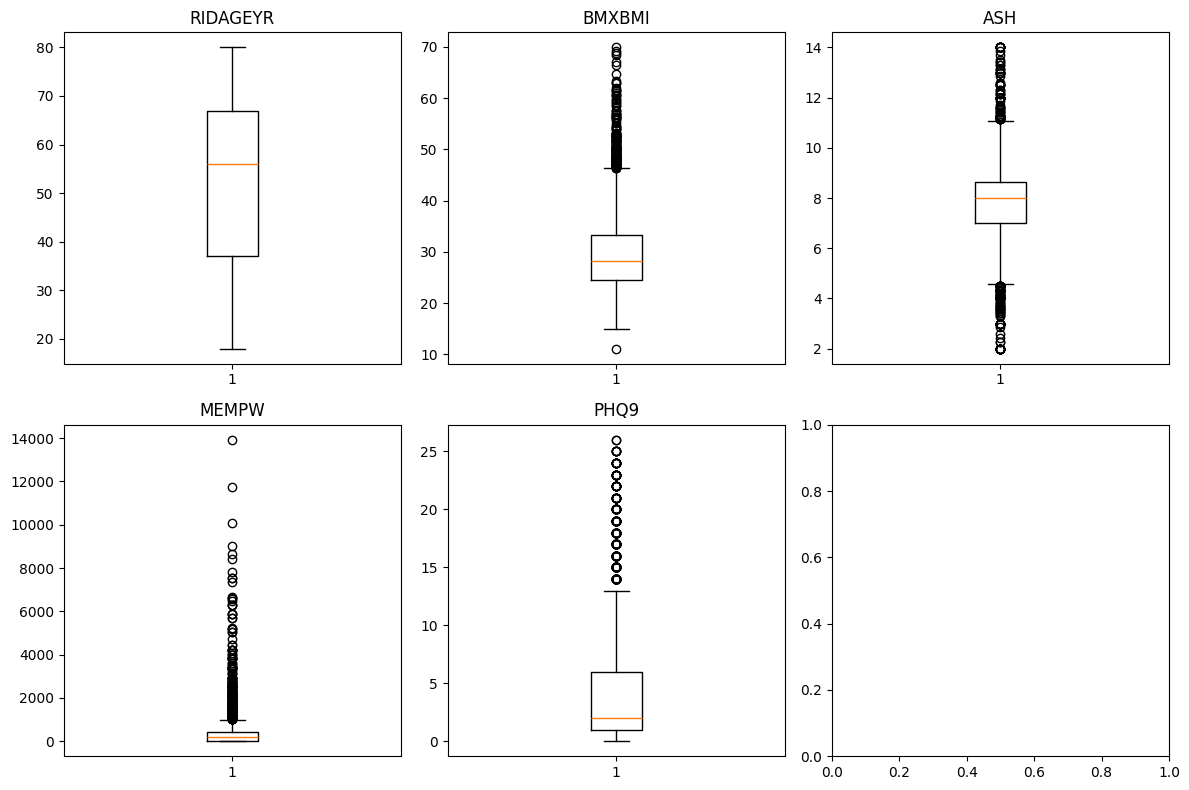

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df_selected_clean[col].dropna())
    axes[idx].set_title(col)
plt.tight_layout()
plt.show()

## Hier auch Check der Rohdaten!!!

In [47]:
# Numerische Spalten auswählen
# numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (df[col] < lower) | (df[col] > upper)

numeric_cols = [ 'SLD012', 'SLD013', \
                         'PAD790Q', 'PAD810Q', \
                         'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060', \
                         'DPQ070', 'DPQ080', 'DPQ090']
for col in numeric_cols:
    mask = detect_outliers(df_selected_clean, col)
    print(f"{col}: {mask.sum()} Ausreisser")

# Statistische Übersicht


# Boxplots für numerische Spalten erstellen


SLD012: 329 Ausreisser
SLD013: 434 Ausreisser
PAD790Q: 55 Ausreisser
PAD810Q: 141 Ausreisser
DPQ010: 250 Ausreisser
DPQ020: 207 Ausreisser
DPQ030: 524 Ausreisser
DPQ040: 463 Ausreisser
DPQ050: 284 Ausreisser
DPQ060: 208 Ausreisser
DPQ070: 195 Ausreisser
DPQ080: 732 Ausreisser
DPQ090: 290 Ausreisser


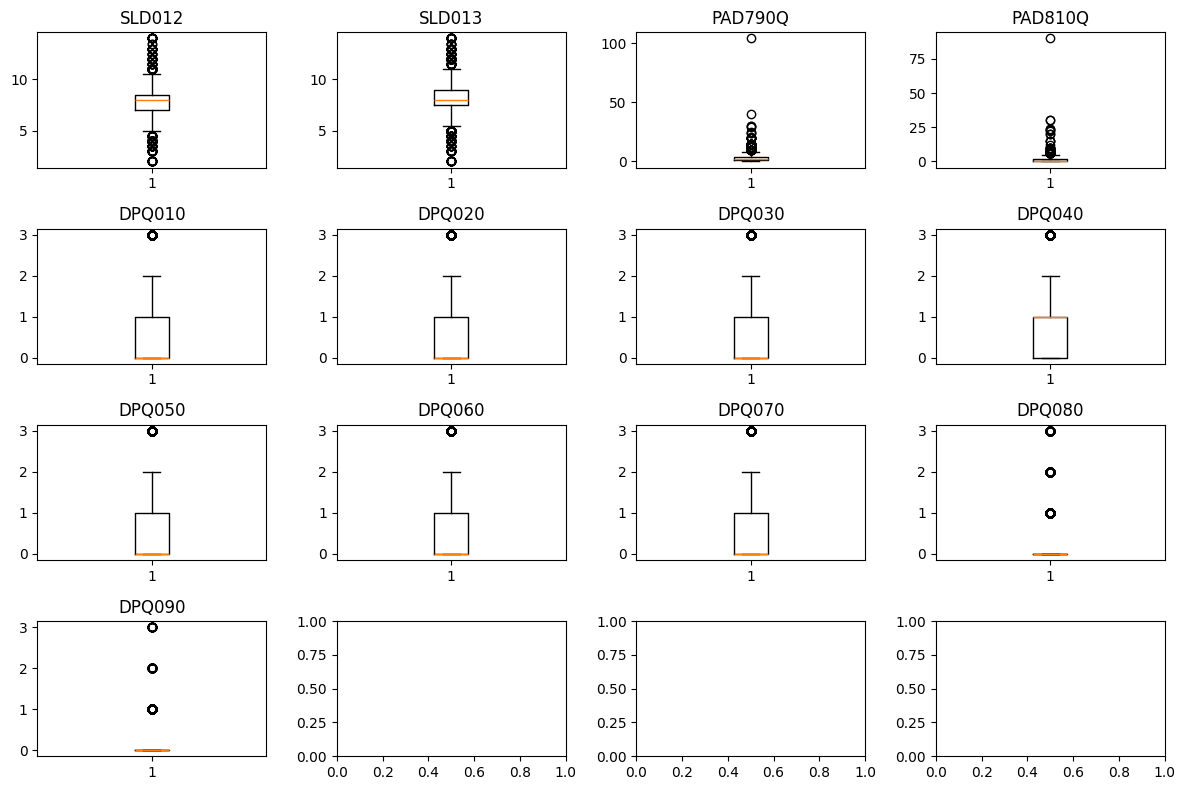

In [48]:
fig, axes = plt.subplots(4, 4, figsize=(12, 8))
axes = axes.flatten()
for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df_selected_clean[col].dropna())
    axes[idx].set_title(col)
plt.tight_layout()
plt.show()

---
## 8. Ausreißer behandeln

**Aufgabe:** Behandeln Sie die identifizierten Ausreißer entsprechend Ihrer Analyse.

**Mögliche Strategien:**
- Ausreißer entfernen (wenn sie Fehler sind)
- Ausreißer behalten (wenn sie valide sind)
- Ausreißer begrenzen (Capping/Flooring)

**Dokumentieren Sie Ihre Entscheidungen!**

Einige Variablen sind bereits gecappt. Allen Probanen, die älter als 80 sind, wurde das Alter 80 zugewiesen.  
Auch die Schlafdauer ist gecappt. Angaben unter 3h sind mit 2h aufgeführt. Angaben über 14h mit 14.  
Auch bei den Minuten und Frequenz-Angaben zur physical activity gab es ein begrenztes Angabeintervall.  
Der PHQ9-Score ist durch die Art ges Scores von vornherein begrenzt. Hier sind Ausreißer einfach starke (aber deshalb keineswegs unrealistische) Ausprägungen.


In [49]:
Q1 = df_selected_clean["BMXBMI"].quantile(0.25)
Q3 = df_selected_clean["BMXBMI"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

lower_outliers = df_selected_clean[df_selected_clean["BMXBMI"] < lower]

print(lower_outliers)

        SEQN  RIAGENDR  RIDAGEYR  DMDEDUC2  DMDMARTZ  BMXBMI  OCD150  SLD012  \
6152  141941         2        66         4         1    11.1       4     7.5   

      SLD013  PAD790Q PAD790U  PAD800  PAD810Q PAD810U  PAD820  DPQ010  \
6152     8.0      0.0             0.0      0.0             0.0       0   

      DPQ020  DPQ030  DPQ040  DPQ050  DPQ060  DPQ070  DPQ080  DPQ090  PHQ9  \
6152       0       3       3       3       0       0       0       0     9   

     DEPS       ASH  MEMPW DEPT  
6152    1  7.642857    0.0    0  


Auch der BMI wurde schon durch die Datenerhebung auf das Intervall 11.1 bis 74.8 begrenzt. Beides extreme Werte, die aber durchaus (deutlich) über-/unterschritten werden können. Auch hier kann man also getrost alle Datenpunkte behalten.

---
## 9. Inkonsistenzen beheben

**Aufgabe:** Suchen Sie nach Inkonsistenzen in kategorialen Spalten.

**Was Sie prüfen sollten:**
- Unterschiedliche Schreibweisen (z.B. "ja", "Ja", "JA")
- Leerzeichen am Anfang oder Ende
- Tippfehler
- Unerwartete Kategorien

Da die kategorialen Variablen numerisch kodiert erhoben wurden, sind Inkonsistenzen aufgrund unterschiedlicher Schreibweisen, Leerzeichen oder Tippfehler ausgeschlossen. Die Überprüfung sowie Vereinheitlichung der Kodierungen erfolgte bereits im Rahmen der Missing-Value-Analyse.  

Die einzige als kategoriale Variable gespeicherte Variable ist die selbst erstellte Variable DEPS. Da sie direkt aus dem PHQ-9-Gesamtscore anhand fest definierter Cut-off-Werte abgeleitet wurde, bedarf sie keiner gesonderten Prüfung auf Inkonsistenzen.

---
## 10. Finale Überprüfung

**Aufgabe:** Führen Sie eine finale Qualitätskontrolle durch.

**Checkliste:**
- ✓ Keine fehlenden Werte (oder bewusst belassen)
- ✓ Keine Duplikate
- ✓ Korrekte Datentypen
- ✓ Ausreißer behandelt
- ✓ Inkonsistenzen behoben
- ✓ Datensatz ist bereit für die Analyse

In [50]:
# Finale Übersicht
print("Finale Dimensionen:")
print(df_selected_clean.shape)

print("\nFehlende Werte:")
print(df_selected_clean.isnull().sum())

print("\nDatentypen:")
print(df_selected_clean.dtypes)

print("\nErste Zeilen des bereinigten Datensatzes:")
print(df_selected_clean.head())


Finale Dimensionen:
(5441, 29)

Fehlende Werte:
SEQN        0
RIAGENDR    0
RIDAGEYR    0
DMDEDUC2    0
DMDMARTZ    0
BMXBMI      0
OCD150      0
SLD012      0
SLD013      0
PAD790Q     0
PAD790U     0
PAD800      0
PAD810Q     0
PAD810U     0
PAD820      0
DPQ010      0
DPQ020      0
DPQ030      0
DPQ040      0
DPQ050      0
DPQ060      0
DPQ070      0
DPQ080      0
DPQ090      0
PHQ9        0
DEPS        0
ASH         0
MEMPW       0
DEPT        0
dtype: int64

Datentypen:
SEQN           int64
RIAGENDR       int64
RIDAGEYR       int64
DMDEDUC2       int64
DMDMARTZ       int64
BMXBMI       float64
OCD150         int64
SLD012       float64
SLD013       float64
PAD790Q      float64
PAD790U       string
PAD800       float64
PAD810Q      float64
PAD810U       string
PAD820       float64
DPQ010         int64
DPQ020         int64
DPQ030         int64
DPQ040         int64
DPQ050         int64
DPQ060         int64
DPQ070         int64
DPQ080         int64
DPQ090         int64
PHQ9           i

In [51]:
print("VERGLEICH")
print(f"Original: {df_merged.shape}")
print(f"Bereinigt: {df_selected_clean.shape}")
print(f"Retention: {(df_selected_clean.shape[0]/df_merged.shape[0]*100):.1f}%")

VERGLEICH
Original: (6337, 76)
Bereinigt: (5441, 29)
Retention: 85.9%


---
## 11. Bereinigten Datensatz speichern

**Aufgabe:** Speichern Sie Ihren bereinigten Datensatz als CSV-Datei.

**Wichtig:** Dieser bereinigte Datensatz wird in den kommenden Wochen für Visualisierung und Machine Learning verwendet!

In [52]:
# Bereinigten Datensatz speichern
df_selected_clean.to_csv('NHANES_depression.csv', index=False)

print("Bereinigter Datensatz wurde gespeichert!")

Bereinigter Datensatz wurde gespeichert!


---
## Reflexion

**Dokumentieren Sie Ihre Arbeit:**

Beantworten Sie folgende Fragen in einer Markdown-Zelle:

1. Welche Hauptprobleme hatte Ihr ursprünglicher Datensatz?
2. Welche Bereinigungsschritte waren am wichtigsten?
3. Wie viele Zeilen/Spalten haben Sie entfernt und warum?
4. Welche Herausforderungen gab es und wie haben Sie diese gelöst?
5. Ist Ihr Datensatz jetzt bereit für die Analyse?

### Ihre Reflexion:

1. **Hauptprobleme:**
   - Verteilung der relevanten Informationen auf mehrere Datensätze
   - Uneinheitliche Kodierung fehlender Werte (missing, „refused“, „don't know“)
   - Nicht direkt nutzbare Variablen, aus denen neue Variablen abgeleitet werden mussten
   - Teilweise unvollständige Angaben in einzelnen Variablen

2. **Wichtigste Schritte:**
   - Zusammenführen der Daten
   - Umgang mit fehlenden Werten (inklusive Zusammenführen der auf verschiedene Arten fehlenden Werte ("kein Wert", "refused" und "don't know")
   - abgeleitete Variablen

3. **Entfernte Daten:**
   - zu Beginng (nach Zusammenführen): (6337, 76)
   - final: (5441, 28) (vier Spalten sind eigene, abgeleitete Variablen)
   - also wurden 896 Zeilen entfernt und 52 Spalten (aber dann  4 neue hinzugefügt)
   - Der Großteil der entfernten Spalten wurde bereits vor der Analyse ausgeschlossen
   - Die Spalten DPQ100 (Difficulty mental health problems have causedund) INDFMPIR (Icome to poverty ratio) wurden gelöscht, weil zu viele Werte gefehlt haben. Einige Zeilen wurden gelöscht, weil es für körperliche Akvitiäten Frequenzen aber keine Einheit gab.

4. **Herausforderungen:**
   - Korrekte Interpretation der Datendokumentation und Kodierungen.
   - Festlegung einer konsistenten Strategie für den Umgang mit fehlenden Werten.
   - Entscheidung, welche Variablen bzw. Beobachtungen aufgrund fehlender Informationen entfernt werden sollten.
   - Erstellen abgeleiteter Variablen (insbesondere das Zusammenführen der Variablen zur körperlichen Aktivität zu einer sinnvollen Variable)

5. **Bereitschaft für Analyse:**
   - Fehlende Werte wurden behandelt
   - irrelevante oder stark unvollständige Variablen wurden entfernt
   - bgeleitete Variablen erstellt
   - es wurden keine zu entfernenden Ausreißer festgestellt
   > Datensatz ist bereit für die Analyse

Helmut Müller

Kommentar Prof. Ipek-Ugay:  

Sehr durchdachte, komplexe Pipeline mit fundiertem Feature Engineering (PHQ9-Score, DEPS-Kategorien, ASH, MEMPW) und vollständiger Retention-Rate. Anbei nur ein ein paar kleine Anmerkungen/Verbesserungsbedarf:
-Versteckte Nullwert-Artefakte (5.397605e-79) ohne Erklärung: In Cell 19 werden tausende solcher Werte auf 0 gesetzt – es fehlt eine kurze Erklärung, woher diese Floating-Point-Artefakte stammen (SAS-Import-Artefakt)
-Duplikat-Check vor dem Merge, nicht nach: Cell 8 prüft Duplikate pro Einzeldatei korrekt; ein Duplikat-Check auf dem zusammengeführten df_merged fehlt **die sind bei dem df_cleaned**
BMXBMI-Imputation mit altem haeufigkeiten-Objekt validiert: Cell 37 gibt nach der Imputation die alte haeufigkeiten-Variable aus (zeigt noch 49 NaN) statt neu zu berechnen – die Ausgabe ist damit irreführend; anzahl_valid wird korrekt aktualisiert, die Verteilung nicht
Ausreißeranalyse nur auf abgeleiteten Variablen: Boxplots und IQR werden auf PHQ9, ASH, MEMPW angewendet, nicht auf die Rohspalten DPQ010–DPQ090, SLD012, SLD013 – ein kurzer Check der Rohdaten wäre vollständiger. sonst wie gesagt super!